# M²ELYody Model's code


Requirements:
  We usedColab Pro


In [25]:
''' Initialization from scratch

!git clone https://github.com/Skyepulse/HacktionPotential1.git
%cd HacktionPotential1
!ls

!pip install huggingface_hub


#%cd MIRepNet
!ls
# This modifies the req2.txt file to remove the strict SciPy upper limit
!sed -i 's/scipy>=1.10.0,<1.11.0/scipy>=1.10.0/' req2.txt

# Now try installing again!
%cd /content/HacktionPotential1/MIRepNet
!pip install -r req2.txt

'''
%cd /content/HacktionPotential1/MIRepNet

/content/HacktionPotential1/MIRepNet


In [26]:
#!sed -i 's/scipy>=1.10.0,<1.11.0/scipy>=1.10.0/' req2.txt
#!ls
#!pip install -r req2.txt


# MIREPnET

In [27]:
# Test installation and imports
import torch
import torch.nn.functional as F
import torchvision
import torchaudio
import numpy as np
import scipy
import mne
import pandas as pd
import sklearn
import matplotlib
import pylsl
import einops
import wandb
import moabb
import tqdm
import time


# Check PyTorch device
if torch.cuda.is_available():
    print(f"PyTorch device: cuda ({torch.cuda.get_device_name(0)})")
else:
    print("PyTorch device: cpu")

PyTorch device: cuda (Tesla T4)


In [28]:
# Import MiRepNet and sanity check model

from model.mlm import mlm_mask

# Instantiate model (adjust emb_size, depth, n_classes as needed)
model = mlm_mask(emb_size=256, depth=6, n_classes=3)  # match checkpoint params

# Load pretrained weights if available
pretrained_path = './weight/MIRepNet.pth'
try:
    state_dict = torch.load(pretrained_path, map_location=torch.device('cpu'))
    model.load_state_dict(state_dict, strict=False)  # allow missing/unexpected keys
    print('Pretrained weights loaded to CPU (non-strict).')
except Exception as e:
    print('Could not load pretrained weights:', e)

# Sanity check: forward pass with dummy data
# shape: (batch, channels, samples)
dummy_input = torch.randn(1, 45, 3000)
with torch.no_grad():
    tic = time.time()
    pooled, logits = model(dummy_input)

probabilities = F.softmax(logits, dim=1) # shape (batch_size, n_classe)
predicted_classes = torch.argmax(probabilities, dim=1) # shape (batch_size)
print("duration = ", time.time() - tic)

print('Sanity check output:', logits)

# print information of the model
#print(model)

Pretrained weights loaded to CPU (non-strict).
duration =  0.2443835735321045
Sanity check output: tensor([[ 3.3322, -1.9911,  0.9487]])


Now that we checked we can load the model without issue, let's test it with real data from "BNCI2014004".

In [29]:
from google.colab import drive

drive.mount('/content/drive')
ROOT = "/content/drive/MyDrive/Colab_Notebooks/Hacktion_Potential/BNCI2014004"

X = np.load(f"{ROOT}/X.npy")
y = np.load(f"{ROOT}/labels.npy")

print("X shape:", X.shape)
print("y shape:", y.shape)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
X shape: (1400, 3, 1000)
y shape: (1400,)


## Our data (27/02/2026)

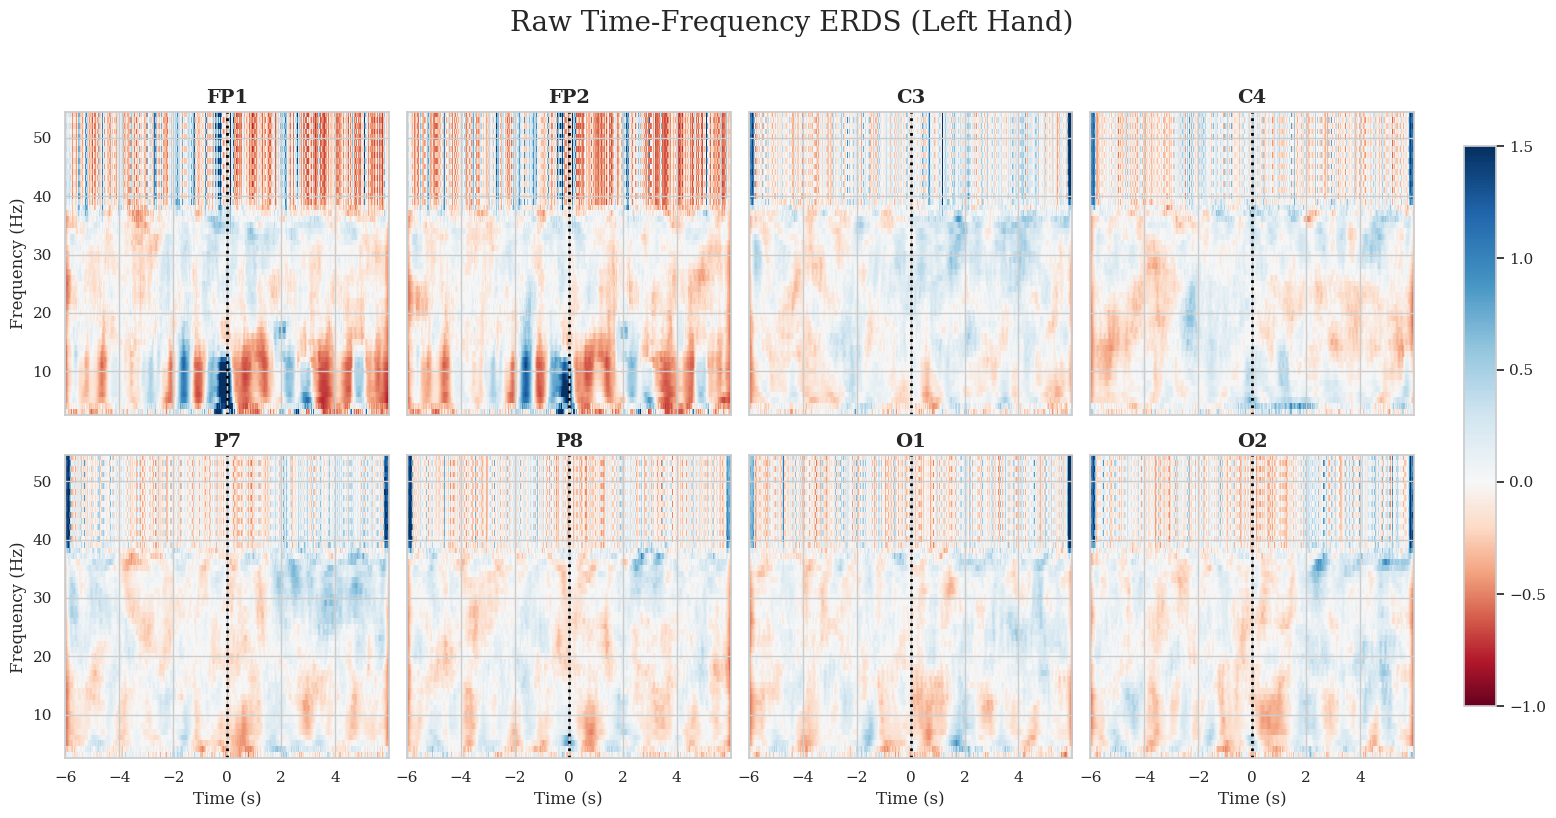

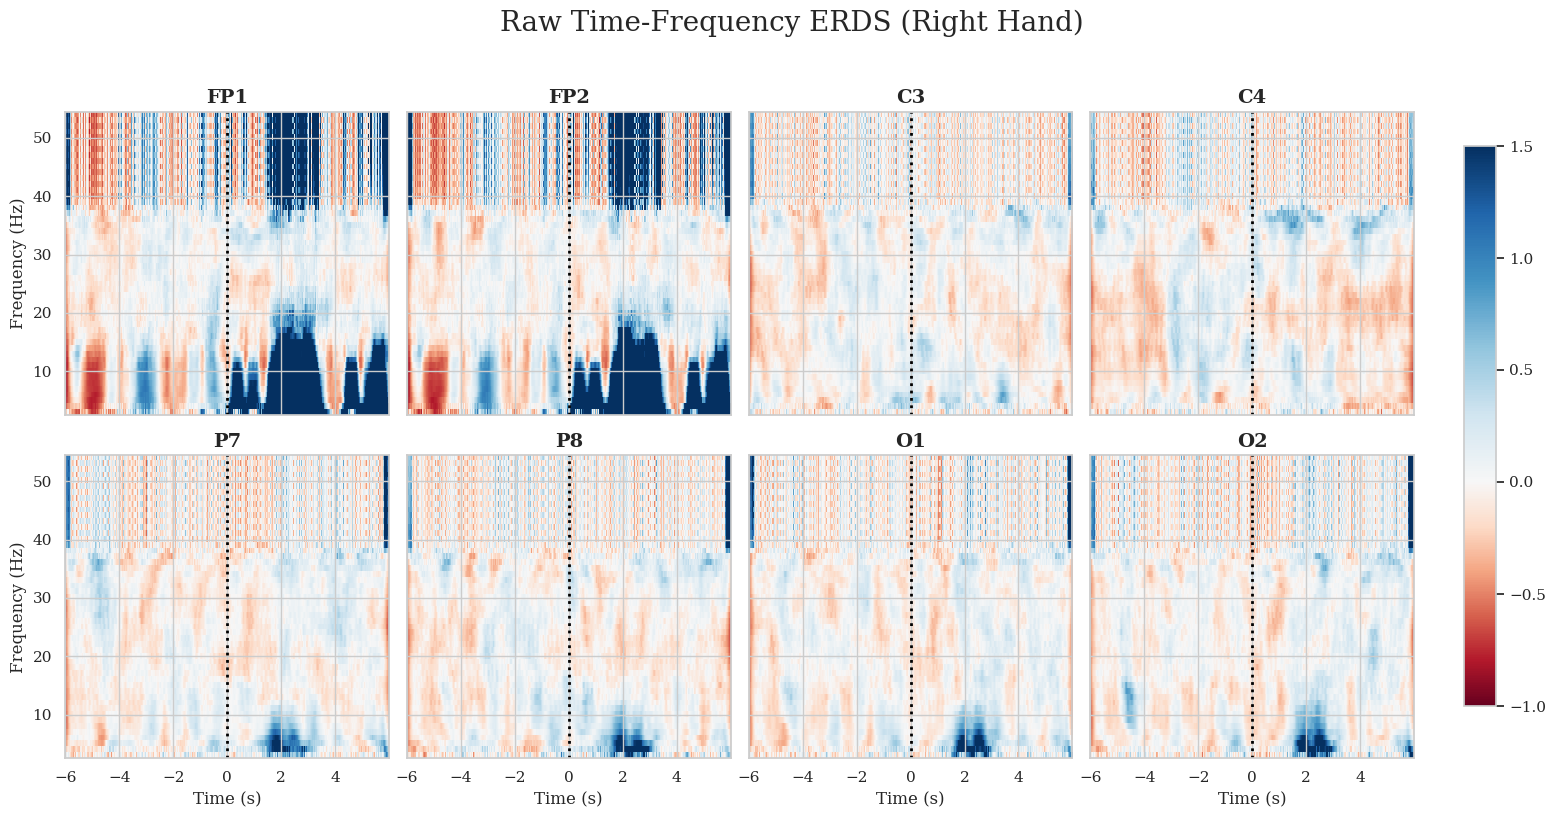

In [30]:
import numpy as np
import mne
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from mne.time_frequency import tfr_multitaper

import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder

from mne.decoding import CSP
from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
import warnings
warnings.filterwarnings("ignore")


# Data folder # Watch out, make sure you have access to my Drive
ROOT_ = "/content/drive/MyDrive/Colab_Notebooks/Hacktion_Potential/"



def load_custom_for_mne(filepath="subject_training.npz", verbose=False):
    data = np.load(filepath)

    X_mi = data['X']   # Shape: (Trials, Time_MI, Channels)
    X_rest = data['z'] # Shape: (Trials, Time_Rest, Channels)
    y_raw = data['y']
    fs = data['fs'].item() if data['fs'].size == 1 else data['fs'][0]

    if verbose:
        print(f"Rest array shape: {X_rest.shape}")
        print(f"MI array shape: {X_mi.shape}")


    X_full = np.concatenate([X_rest, X_mi], axis=1)

    # Transpose to MNE format: (Trials, Channels, Time)
    X_full = np.transpose(X_full, (0, 2, 1))

    rest_samples = X_rest.shape[1]
    tmin = -(rest_samples / fs)
    tmax = X_mi.shape[1] / fs
    return X_full, y_raw, fs, tmin, tmax


# Load the data
X_epochs, y_labels, fs, tmin, tmax = load_custom_for_mne(ROOT_+"subject_training.npz")
X_volts = X_epochs * 1e-6

# Channel labels
ch_names = ['FP1', 'FP2', 'C3', 'C4', 'P7', 'P8', 'O1', 'O2']


info = mne.create_info(ch_names=ch_names, sfreq=fs, ch_types='eeg')
epochs = mne.EpochsArray(X_volts, info, tmin=tmin)

# Map the labels (0=LEFT, 1=RIGHT)
event_id = {'Left Hand': 0, 'Right Hand': 1}
epochs.events[:, 2] = y_labels
epochs.event_id = event_id


# Filtering out DC offset and artifacts...
epochs.filter(l_freq=8.0, h_freq=30.0)

# CALCULATE TIME-FREQUENCY REPRESENTATION (TFR)
freqs = np.arange(3, 55) # 3 Hz to 55 Hz
tfr = tfr_multitaper(
    epochs, freqs=freqs, n_cycles=freqs/2, use_fft=True,
    return_itc=False, average=False, decim=2
)

# Apply baseline correction (using the rest period & we crop to avoid edge artifacts
tfr.crop(tmin, tmax).apply_baseline((tmin + 0.5, 0.0 - 0.5), mode="percent")

# Unmasked Spectrogram of the 8 channels
vmin, vmax = -1, 1.5
cnorm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

for event in event_id:
    # Average the trials for this specific condition
    tfr_ev = tfr[event].average()

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

    for ch, ax in enumerate(axes):
        # Plot the ERDS map for this channel
        img = tfr_ev.plot([ch], cmap="RdBu", cnorm=cnorm, axes=ax, colorbar=False, show=False)
        ax.set_title(epochs.ch_names[ch], fontsize=14, fontweight='bold')

        ax.axvline(0, linewidth=2, color="black", linestyle=":") # cue line T=0

        # Clean up labels so it's not too cluttered
        if ch % 4 != 0: # Only show Y-axis (Frequency) on the left-most plots
            ax.set_ylabel("")
            ax.set_yticklabels("")
        if ch < 4:      # Only show X-axis (Time) on the bottom row
            ax.set_xlabel("")
            ax.set_xticklabels("")

    # Add a single colorbar for the whole figure
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7]) # [left, bottom, width, height]
    fig.colorbar(axes[0].images[-1], cax=cbar_ax).ax.set_yscale("linear")

    fig.suptitle(f"Raw Time-Frequency ERDS ({event})", fontsize=20, y=1.02)
    plt.tight_layout(rect=[0, 0, 0.9, 1]) # Leave room for the colorbar
    plt.show()

Calculating Contrast Map (Left Hand - Right Hand)...


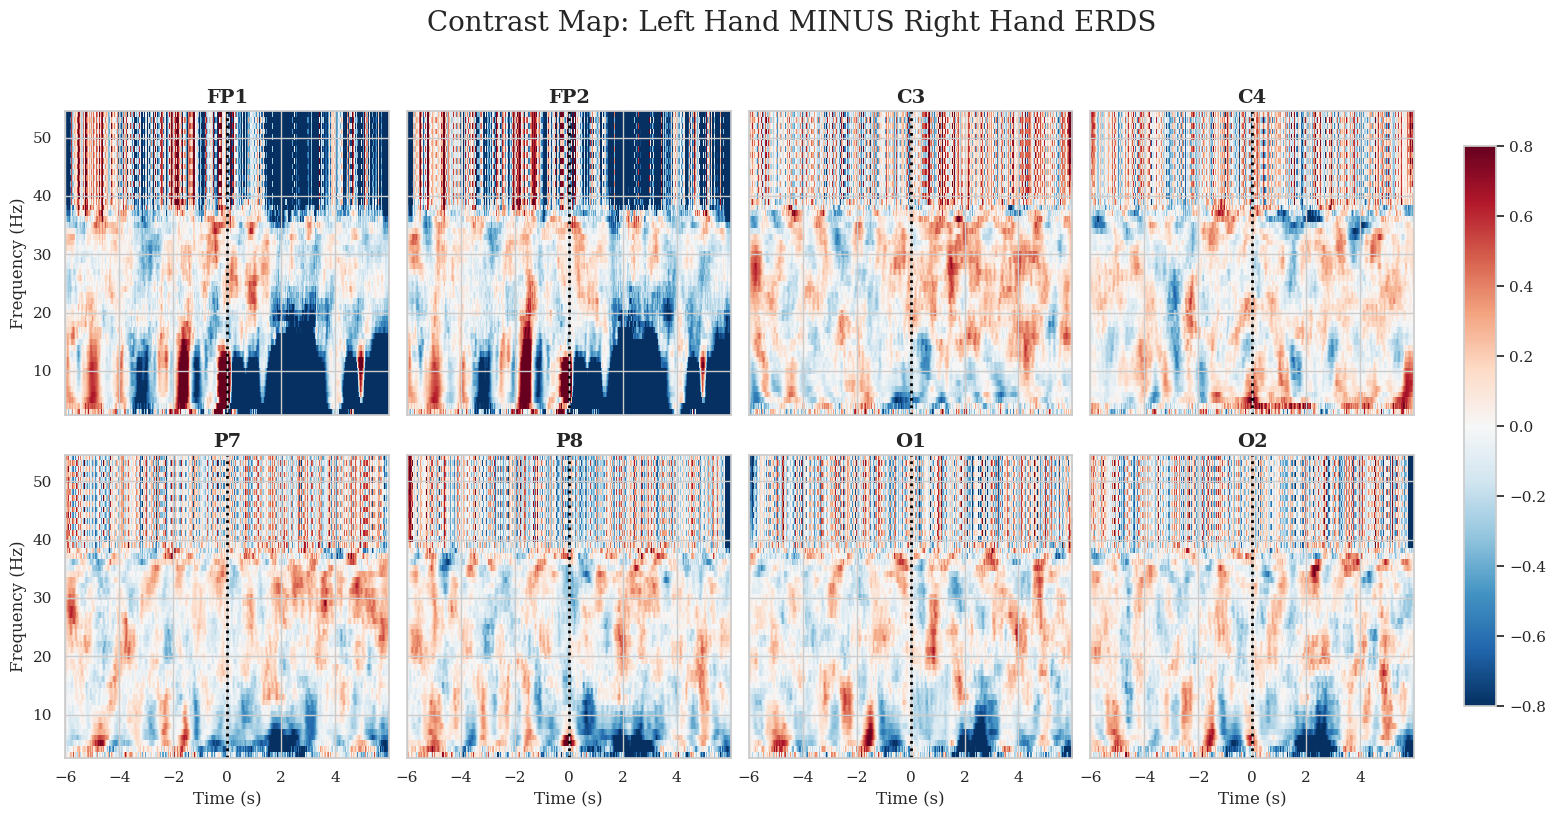

In [31]:
# ==========================================
# PLOT THE DIFFERENCE MAP (LEFT minus RIGHT)
# ==========================================
print("Calculating Contrast Map (Left Hand - Right Hand)...")

# 1. Average the trials for each condition
tfr_left = tfr['Left Hand'].average()
tfr_right = tfr['Right Hand'].average()

# 2. Subtract the two conditions! MNE handles the matrix math automatically.
# Positive values (Red) mean Left > Right (Right has more ERD/power drop)
# Negative values (Blue) mean Left < Right (Left has more ERD/power drop)
tfr_diff = tfr_left - tfr_right

# 3. Setup the plot
# We use a slightly tighter color norm for the difference map to highlight subtleties
diff_vmin, diff_vmax = -0.8, 0.8
cnorm_diff = TwoSlopeNorm(vmin=diff_vmin, vcenter=0, vmax=diff_vmax)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ch, ax in enumerate(axes):
    # Plot the Difference map for this channel
    img = tfr_diff.plot([ch], cmap="RdBu_r", cnorm=cnorm_diff, axes=ax, colorbar=False, show=False)
    ax.set_title(epochs.ch_names[ch], fontsize=14, fontweight='bold')

    # Draw the cue line (Time = 0.0)
    ax.axvline(0, linewidth=2, color="black", linestyle=":")

    # Clean up labels
    if ch % 4 != 0:
        ax.set_ylabel("")
        ax.set_yticklabels("")
    if ch < 4:
        ax.set_xlabel("")
        ax.set_xticklabels("")

# Add colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(axes[0].images[-1], cax=cbar_ax).ax.set_yscale("linear")

fig.suptitle("Contrast Map: Left Hand MINUS Right Hand ERDS", fontsize=20, y=1.02)
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

### RG+LR model trained on subsampled channels [2,3,4,5]

In [32]:
import joblib


mne.set_log_level("WARNING") # This shuts off the "Info" logs

def load_custom_dataset(filepath="subject_training.npz", verbose=False):
    if verbose:
      print(f"Loading custom dataset: {filepath}")
    data = np.load(filepath)

    X_raw = data['X']  # Shape: (trials, samples, channels)
    y_raw = data['y']  # Shape: (trials,)
    Z_raw = data['z']  # Shape: (trials, samples, channels)
    fs = data['fs'].item() if data['fs'].size == 1 else data['fs'][0]

    if verbose:
        print(f"Original X shape: {X_raw.shape}")
        print(f"Original Z shape: {X_raw.shape}")

    # Transpose to (Trials, Channels, Time)
    X_transposed = np.transpose(X_raw, (0, 2, 1))
    Z_transposed = np.transpose(Z_raw, (0, 2, 1))

    if verbose:
      print(f"Transposed X shape (for ML): {X_transposed.shape}")
      print(f"Transposed Z shape (for ML): {Z_transposed.shape}")

    return X_transposed, Z_transposed ,y_raw, fs


def apply_bandpass(data, lowcut=8.0, highcut=30.0, fs=250.0, order=4):
    """Filters data along the time axis (which is now axis -1)"""
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, data, axis=-1)




# ==========================================
# 3. DEFINE TRADITIONAL ML PIPELINES
# ==========================================
pipelines = {}

pipelines["CSP+LDA"] = make_pipeline(CSP(n_components=4), LDA())

pipelines["RG+LR"] = make_pipeline(
    Covariances(estimator="oas"),
    TangentSpace(),
    LogisticRegression(solver="lbfgs")
)

pipelines["RG+MLP"] = make_pipeline(
    Covariances(),
    TangentSpace(),
    MLPClassifier(hidden_layer_sizes=(256, 256),activation='tanh',max_iter=1000)
)

pipelines["RG+SVM"] = make_pipeline(
    Covariances(estimator="oas"),
    TangentSpace(),
    SVC(kernel="rbf")
)



# ==========================================
# 4. EXECUTION
# ==========================================
verbose = False
if __name__ == "__main__":
    # Load and format the data
    X_raw, Z_raw, y_raw, fs = load_custom_dataset(ROOT_+"subject_training.npz",verbose=verbose)

    # Apply filter Motor Imagery Filter
    X_filt = apply_bandpass(X_raw, lowcut=8.0, highcut=30.0, fs=fs)
    Z_filt = apply_bandpass(Z_raw, lowcut=8.0, highcut=30.0, fs=fs)

    # Ensures labels are 0 and 1
    if np.unique(y_raw).tolist() == [0, 1]:
        y = y_raw
    else:
      le = LabelEncoder()
      y = le.fit_transform(y_raw)

    if verbose:
        print(f"Total Trials: {len(y)} (Class 0: {sum(y==0)}, Class 1: {sum(y==1)})")


    # Set up 5-Fold Cross Validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    all_results = []

    #print("\n" + "="*40)
    #print("STARTING 5-FOLD CROSS-VALIDATION")
    #print("="*40)
    X_filt_motor_only = X_filt[:, [2,3,4,5], :]
    X_filt = X_filt_motor_only


    for pipe_name, pipeline in pipelines.items():
        # cross_val_score handles the fitting and scoring automatically for each fold
        scores = cross_val_score(pipeline, X_filt, y, cv=cv, scoring='accuracy')

        mean_acc = scores.mean() * 100
        std_acc = scores.std() * 100

        print(f"{pipe_name:10s} | Mean Acc: {mean_acc:.2f}% (+/- {std_acc:.2f}%)")


best_pipeline = pipelines["RG+LR"]
best_pipeline.fit(X_filt_motor_only, y)
model_filename = ROOT_ + "bci_rgLR_model.joblib"
joblib.dump(best_pipeline, model_filename)
print(f"Success! Model exported to: {model_filename}")

CSP+LDA    | Mean Acc: 65.00% (+/- 12.25%)
RG+LR      | Mean Acc: 68.33% (+/- 14.34%)
RG+MLP     | Mean Acc: 66.67% (+/- 9.13%)
RG+SVM     | Mean Acc: 53.33% (+/- 17.95%)
Success! Model exported to: /content/drive/MyDrive/Colab_Notebooks/Hacktion_Potential/bci_rgLR_model.joblib


### RG+SVM model trained on all channels

In [33]:
import joblib


mne.set_log_level("WARNING") # This shuts off the "Info" logs

def load_custom_dataset(filepath="subject_training.npz", verbose=False):
    if verbose:
      print(f"Loading custom dataset: {filepath}")
    data = np.load(filepath)

    X_raw = data['X']  # Shape: (trials, samples, channels)
    y_raw = data['y']  # Shape: (trials,)
    Z_raw = data['z']  # Shape: (trials, samples, channels)
    fs = data['fs'].item() if data['fs'].size == 1 else data['fs'][0]

    if verbose:
        print(f"Original X shape: {X_raw.shape}")
        print(f"Original Z shape: {X_raw.shape}")

    # Transpose to (Trials, Channels, Time)
    X_transposed = np.transpose(X_raw, (0, 2, 1))
    Z_transposed = np.transpose(Z_raw, (0, 2, 1))

    if verbose:
      print(f"Transposed X shape (for ML): {X_transposed.shape}")
      print(f"Transposed Z shape (for ML): {Z_transposed.shape}")

    return X_transposed, Z_transposed ,y_raw, fs


def apply_bandpass(data, lowcut=8.0, highcut=30.0, fs=250.0, order=4):
    """Filters data along the time axis (which is now axis -1)"""
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, data, axis=-1)




# ==========================================
# 3. DEFINE TRADITIONAL ML PIPELINES
# ==========================================
pipelines = {}

pipelines["CSP+LDA"] = make_pipeline(CSP(n_components=4), LDA())

pipelines["RG+LR"] = make_pipeline(
    Covariances(estimator="oas"),
    TangentSpace(),
    LogisticRegression(solver="lbfgs")
)

pipelines["RG+MLP"] = make_pipeline(
    Covariances(),
    TangentSpace(),
    MLPClassifier(hidden_layer_sizes=(256, 256),activation='tanh',max_iter=1000)
)

pipelines["RG+SVM"] = make_pipeline(
    Covariances(estimator="oas"),
    TangentSpace(),
    SVC(kernel="rbf")
)



# ==========================================
# 4. EXECUTION
# ==========================================
verbose = False
if __name__ == "__main__":
    # Load and format the data
    X_raw, Z_raw, y_raw, fs = load_custom_dataset(ROOT_+"subject_training.npz",verbose=verbose)

    # Apply filter Motor Imagery Filter
    X_filt = apply_bandpass(X_raw, lowcut=8.0, highcut=30.0, fs=fs)
    Z_filt = apply_bandpass(Z_raw, lowcut=8.0, highcut=30.0, fs=fs)

    # Ensures labels are 0 and 1
    if np.unique(y_raw).tolist() == [0, 1]:
        y = y_raw
    else:
      le = LabelEncoder()
      y = le.fit_transform(y_raw)

    if verbose:
        print(f"Total Trials: {len(y)} (Class 0: {sum(y==0)}, Class 1: {sum(y==1)})")


    # Set up 5-Fold Cross Validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    all_results = []

    #print("\n" + "="*40)
    #print("STARTING 5-FOLD CROSS-VALIDATION")
    #print("="*40)

    for pipe_name, pipeline in pipelines.items():
        # cross_val_score handles the fitting and scoring automatically for each fold
        scores = cross_val_score(pipeline, X_filt, y, cv=cv, scoring='accuracy')

        mean_acc = scores.mean() * 100
        std_acc = scores.std() * 100

        print(f"{pipe_name:10s} | Mean Acc: {mean_acc:.2f}% (+/- {std_acc:.2f}%)")


best_pipeline = pipelines["RG+SVM"]
best_pipeline.fit(X_filt_motor_only, y)
model_filename = ROOT_ + "bci_rgSVM_model.joblib"
joblib.dump(best_pipeline, model_filename)
print(f"Success! Model exported to: {model_filename}")

CSP+LDA    | Mean Acc: 66.67% (+/- 11.79%)
RG+LR      | Mean Acc: 76.67% (+/- 11.06%)
RG+MLP     | Mean Acc: 68.33% (+/- 9.72%)
RG+SVM     | Mean Acc: 78.33% (+/- 11.30%)
Success! Model exported to: /content/drive/MyDrive/Colab_Notebooks/Hacktion_Potential/bci_rgSVM_model.joblib


In [34]:
import numpy as np
import joblib
from scipy.signal import butter, filtfilt
import time


# Load model
MODEL_PATH_EOG = "/content/drive/MyDrive/Colab_Notebooks/Hacktion_Potential/bci_rgSVM_model.joblib"
MODEL_PATH_EEG = "/content/drive/MyDrive/Colab_Notebooks/Hacktion_Potential/bci_rgLR_model.joblib"




from sklearn.metrics import accuracy_score, confusion_matrix

print("\n" + "="*40)
print("TESTING LOADED MODEL ON TRAINING DATA")

# 1. Load the model back from the hard drive
model_EOG = joblib.load(MODEL_PATH_EOG)
model_EEG = joblib.load(MODEL_PATH_EEG)


# 2. Run inference on the exact data it was trained on
predictions_EOG = model_EOG.predict(X_filt_motor_only)
predictions_EEG = model_EEG.predict(X_filt_motor_only)


# 3. Calculate and display the results
train_accuracy = accuracy_score(y, predictions_EOG) * 100
conf_matrix = confusion_matrix(y, predictions_EOG)

print(f"\nTraining Data Accuracy: {train_accuracy:.2f}%")
print("Confusion Matrix:")
print(f"               Predicted Left | Predicted Right")
print(f"Actual Left  | {conf_matrix[0,0]:14d} | {conf_matrix[0,1]:15d}")
print(f"Actual Right | {conf_matrix[1,0]:14d} | {conf_matrix[1,1]:15d}")


train_accuracy = accuracy_score(y, predictions_EEG) * 100
conf_matrix = confusion_matrix(y, predictions_EEG)

print(f"\nTraining Data Accuracy: {train_accuracy:.2f}%")
print("Confusion Matrix:")
print(f"               Predicted Left | Predicted Right")
print(f"Actual Left  | {conf_matrix[0,0]:14d} | {conf_matrix[0,1]:15d}")
print(f"Actual Right | {conf_matrix[1,0]:14d} | {conf_matrix[1,1]:15d}")



TESTING LOADED MODEL ON TRAINING DATA

Training Data Accuracy: 83.33%
Confusion Matrix:
               Predicted Left | Predicted Right
Actual Left  |             24 |               6
Actual Right |              4 |              26

Training Data Accuracy: 73.33%
Confusion Matrix:
               Predicted Left | Predicted Right
Actual Left  |             22 |               8
Actual Right |              8 |              22


Now let's try with big deep learning

In [35]:


import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from scipy.signal import butter, filtfilt

# Import the necessary functions from MIRepNet utils
from utils.utils import EA, pad_missing_channels_diff, train, validate
from utils.channel_list import use_channels_names
from model.mlm import mlm_mask

# --- 1. CUSTOM DATA LOADING FUNCTION ---
def load_custom_dataset(filepath="subject_training.npz"):
    print(f"Loading custom dataset: {filepath}")
    data = np.load(filepath)

    X_raw = data['X']  # LSL saves as (Trials, Time, Channels)
    y_raw = data['y']  # (Trials,)
    fs = data['fs'].item() if data['fs'].size == 1 else data['fs'][0]

    # CRITICAL: Transpose to (Trials, Channels, Time) for PyTorch/EA
    X_transposed = np.transpose(X_raw, (0, 2, 1))
    return X_transposed, y_raw, fs

# --- 2. PREPROCESSING FUNCTIONS ---
def apply_bandpass(data, lowcut=8.0, highcut=30.0, fs=250.0, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, data, axis=-1)

# ==========================================
# EXPERIMENT SETUP
# ==========================================
if __name__ == "__main__":
    # 1. Load your custom data
    X_raw, y_raw, fs = load_custom_dataset(ROOT_+"subject_training.npz")

    # Encode Labels
    le = LabelEncoder()
    y = le.fit_transform(y_raw)

    # 2. DEFINE YOUR HEADSET CHANNELS HERE!
    # These must match the names in `utils.channel_list` dictionary
    # Example placeholder: (Please update to your actual 8 electrodes)
    MY_8_CHANNELS = ['FP1', 'FP2', 'C3', 'C4', 'P7', 'P8', 'O1', 'O2']

    # 3. Preprocess the entire dataset (Filter -> EA -> Interpolate)
    print("\nPreprocessing Entire Dataset...")
    X_filt = apply_bandpass(X_raw, fs=fs)
    X_ea = EA(X_filt).astype(np.float32)
    X_padded = pad_missing_channels_diff(
        X_ea,
        use_channels_names, # The 45 target template channels
        MY_8_CHANNELS       # Your 8 actual physical channels
    )

    print(f"Final Data Shape for Model: {X_padded.shape}")

    # ==========================================
    # CROSS-VALIDATION & PYTORCH TRAINING
    # ==========================================
    n_splits = 5
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"\nTraining on: {device}")

    batch_size = 8
    epochs = 10
    accuracies_per_fold = []

    for fold, (train_idx, val_idx) in enumerate(cv.split(X_padded, y)):
        print(f"\n" + "="*30)
        print(f"=== Fold {fold+1}/{n_splits} ===")
        print("="*30)

        # Split data for this fold
        X_train, X_val = X_padded[train_idx], X_padded[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        # Create DataLoaders
        train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
        val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.long))

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        # CRITICAL: Re-instantiate the model, optimizer, and scheduler inside the loop
        # so each fold starts fresh from the pretrained weights!
        model = mlm_mask(
            emb_size=256,
            depth=6,
            n_classes=2,
            pretrainmode=False,
            pretrain='./weight/MIRepNet.pth'
        ).to(device)

        optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
        criterion = nn.CrossEntropyLoss()
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

        final_val_acc = 0.0

        # Training Loop for this Fold
        for epoch in range(epochs):
            train_loss, train_acc, curr_lr = train(model, train_loader, criterion, optimizer, device, scheduler)
            val_loss, val_acc = validate(model, val_loader, criterion, device)

            final_val_acc = val_acc # Track the last epoch's accuracy

            if (epoch + 1) % 10 == 0 or epoch == 0:
                print(f"Epoch [{epoch+1:02d}/{epochs}] "
                      f"| Train Loss: {train_loss:.4f} | Train Acc: {train_acc:5.2f}% "
                      f"| Val Loss: {val_loss:.4f} | Val Acc: {val_acc:5.2f}%")

        accuracies_per_fold.append(final_val_acc)
        print(f"Fold {fold+1} Completed. Validation Accuracy: {final_val_acc:.2f}%")

    # ==========================================
    # FINAL RESULTS
    # ==========================================
    print("\n" + "="*40)
    print("FINAL 5-FOLD CROSS-VALIDATION RESULTS")
    print("="*40)
    for i, acc in enumerate(accuracies_per_fold):
        print(f"Fold {i+1}: {acc:.2f}%")
    print("-" * 40)
    print(f"Average Accuracy: {np.mean(accuracies_per_fold):.2f}% (+/- {np.std(accuracies_per_fold):.2f}%)")
    print("="*40)

Loading custom dataset: /content/drive/MyDrive/Colab_Notebooks/Hacktion_Potential/subject_training.npz

Preprocessing Entire Dataset...
Final Data Shape for Model: (60, 45, 1500)

Training on: cuda

=== Fold 1/5 ===
Loaded 108/110 parameters from pretrained model
Epoch [01/10] | Train Loss: 0.7038 | Train Acc: 52.08% | Val Loss: 0.6892 | Val Acc: 41.67%
Epoch [10/10] | Train Loss: 0.6732 | Train Acc: 68.75% | Val Loss: 0.7172 | Val Acc: 41.67%
Fold 1 Completed. Validation Accuracy: 41.67%

=== Fold 2/5 ===
Loaded 108/110 parameters from pretrained model
Epoch [01/10] | Train Loss: 0.7039 | Train Acc: 41.67% | Val Loss: 0.6895 | Val Acc: 50.00%
Epoch [10/10] | Train Loss: 0.6727 | Train Acc: 64.58% | Val Loss: 0.6841 | Val Acc: 58.33%
Fold 2 Completed. Validation Accuracy: 58.33%

=== Fold 3/5 ===
Loaded 108/110 parameters from pretrained model
Epoch [01/10] | Train Loss: 0.7088 | Train Acc: 39.58% | Val Loss: 0.6862 | Val Acc: 50.00%
Epoch [10/10] | Train Loss: 0.6811 | Train Acc: 64.5

It seems to completely overfit

====> Let's try to enhance the model

In [36]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import StratifiedKFold
from scipy.signal import butter, filtfilt

# Import the necessary functions from MIRepNet utils
from utils.utils import EA, pad_missing_channels_diff, train, validate
from utils.channel_list import use_channels_names
from model.mlm import mlm_mask

# --- 1. CUSTOM DATA LOADING FUNCTION ---
def load_custom_dataset(filepath="subject_training.npz"):
    print(f"Loading custom dataset: {filepath}")
    data = np.load(filepath)

    X_raw = data['X']  # LSL saves as (Trials, Time, Channels)
    y_raw = data['y']  # (Trials,)
    Z_raw = data['z']  # (Trials, Time, Channels)
    fs = data['fs'].item() if data['fs'].size == 1 else data['fs'][0]

    # CRITICAL: Transpose to (Trials, Channels, Time) for PyTorch/EA
    X_transposed = np.transpose(X_raw, (0, 2, 1))
    Z_transposed = np.transpose(Z_raw, (0, 2, 1))

    return X_transposed, Z_transposed, y_raw, fs

# --- 2. PREPROCESSING FUNCTIONS ---
def apply_bandpass(data, lowcut=8.0, highcut=30.0, fs=250.0, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, data, axis=-1)

# ==========================================
# EXPERIMENT SETUP
# ==========================================
if __name__ == "__main__":
    # 1. Load your custom data
    ROOT_ = "/content/drive/MyDrive/Colab_Notebooks/Hacktion_Potential/"
    X_raw, Z_raw, y_raw, fs = load_custom_dataset(ROOT_ + "subject_training.npz")

    # Encode Labels
    le = LabelEncoder()
    y = le.fit_transform(y_raw)

    print(f"Total Trials: {len(y)} (Left: {sum(y==0)}, Right: {sum(y==1)})")

    # ==========================================
    # CRITICAL FIX 1: THE "TRUE BCI" CHANNEL SLICE
    # ==========================================
    # Keep ONLY C3, C4, P7, P8 (Indices 2, 3, 4, 5) to avoid eye blinks
    print("\nSlicing data to keep only Motor/Parietal channels...")
    X_motor_only = X_raw[:, [2, 3, 4, 5], :]

    # Update the names list to match the 4 channels we just isolated
    #MY_8_CHANNELS = ['FP1', 'FP2', 'C3', 'C4', 'P7', 'P8', 'O1', 'O2']
    MY_MOTOR_CHANNELS = [ 'C3', 'C4', 'P7', 'P8']

    # ==========================================
    # PREPROCESSING
    # ==========================================
    print("\nPreprocessing Dataset...")
    X_filt = apply_bandpass(X_motor_only, fs=fs)
    X_ea = EA(X_filt).astype(np.float32)
    X_padded = pad_missing_channels_diff(
        X_ea,
        use_channels_names, # The 45 target template channels
        MY_MOTOR_CHANNELS   # Your 4 clean physical channels
    )

    # ==========================================
    # CRITICAL FIX 2: CROP TIME DIMENSION
    # ==========================================
    # Crop from 1500 down to 1000 to perfectly match the pre-trained Positional Embeddings
    X_final = X_padded[:, :, 250:1250]

    print(f"Final Data Shape for Model: {X_final.shape}") # MUST be (60, 45, 1000)

    # ==========================================
    # CROSS-VALIDATION & PYTORCH TRAINING
    # ==========================================
    n_splits = 5
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"\nTraining on: {device}")

    batch_size = 8
    # We can lower epochs back to 30 since we are using the fully pre-trained head
    epochs = 30
    accuracies_per_fold = []

    for fold, (train_idx, val_idx) in enumerate(cv.split(X_final, y)):
        print(f"\n" + "="*30)
        print(f"=== Fold {fold+1}/{n_splits} ===")
        print("="*30)

        # Split data for this fold
        X_train, X_val = X_final[train_idx], X_final[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        # Create DataLoaders
        train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
        val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.long))

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        # Re-instantiate the 2-Class model
        model = mlm_mask(
            emb_size=256,
            depth=6,
            n_classes=2, # Back to 2 classes!
            pretrainmode=False,
            pretrain='./weight/MIRepNet.pth'
        ).to(device)

        # Use a slightly higher weight decay (1e-4) to prevent overfitting on 60 trials
        optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
        criterion = nn.CrossEntropyLoss()
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

        final_val_acc = 0.0

        # Training Loop for this Fold
        for epoch in range(epochs):
            train_loss, train_acc, curr_lr = train(model, train_loader, criterion, optimizer, device, scheduler)
            val_loss, val_acc = validate(model, val_loader, criterion, device)

            final_val_acc = val_acc

            if (epoch + 1) % 10 == 0 or epoch == 0:
                print(f"Epoch [{epoch+1:02d}/{epochs}] "
                      f"| Train Loss: {train_loss:.4f} | Train Acc: {train_acc:5.2f}% "
                      f"| Val Loss: {val_loss:.4f} | Val Acc: {val_acc:5.2f}%")

        accuracies_per_fold.append(final_val_acc)
        print(f"Fold {fold+1} Completed. Validation Accuracy: {final_val_acc:.2f}%")

    print("\n" + "="*40)
    print("FINAL 5-FOLD CROSS-VALIDATION RESULTS (2-Class, Motor Only)")
    print("="*40)
    for i, acc in enumerate(accuracies_per_fold):
        print(f"Fold {i+1}: {acc:.2f}%")
    print("-" * 40)
    print(f"Average Accuracy: {np.mean(accuracies_per_fold):.2f}% (+/- {np.std(accuracies_per_fold):.2f}%)")
    print("="*40)



# ==========================================
# FINAL PRODUCTION MODEL (TRAIN & SAVE)
# ==========================================
print("\n" + "="*40)
print("TRAINING FINAL MODEL ON ALL DATA")
print("="*40)

# 1. Instantiate a fresh model
final_model = mlm_mask(
    emb_size=256,
    depth=6,
    n_classes=2,
    pretrainmode=False,
    pretrain='./weight/MIRepNet.pth'
).to(device)

# 2. Setup optimizer and criterion
optimizer = optim.Adam(final_model.parameters(), lr=1e-4, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

# 3. Create a single DataLoader containing ALL 60 trials
final_dataset = TensorDataset(torch.tensor(X_final, dtype=torch.float32), torch.tensor(y, dtype=torch.long))
final_loader = DataLoader(final_dataset, batch_size=batch_size, shuffle=True)

# 4. Train the final model
final_model.train()
for epoch in range(epochs):
    train_loss, train_acc, curr_lr = train(final_model, final_loader, criterion, optimizer, device, scheduler)
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:02d}/{epochs}] | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:5.2f}%")

# 5. Export the weights to your Google Drive
final_model_path = ROOT_ + "mirepnet_custom_weights.pth"
torch.save(final_model.state_dict(), final_model_path)
print(f"\nSuccess! Final model weights saved to: {final_model_path}")

Loading custom dataset: /content/drive/MyDrive/Colab_Notebooks/Hacktion_Potential/subject_training.npz
Total Trials: 60 (Left: 30, Right: 30)

Slicing data to keep only Motor/Parietal channels...

Preprocessing Dataset...
Final Data Shape for Model: (60, 45, 1000)

Training on: cuda

=== Fold 1/5 ===
Loaded 108/110 parameters from pretrained model
Epoch [01/30] | Train Loss: 0.7153 | Train Acc: 45.83% | Val Loss: 0.7404 | Val Acc: 50.00%
Epoch [10/30] | Train Loss: 0.6259 | Train Acc: 66.67% | Val Loss: 0.6877 | Val Acc: 66.67%
Epoch [20/30] | Train Loss: 0.4983 | Train Acc: 79.17% | Val Loss: 0.7076 | Val Acc: 58.33%
Epoch [30/30] | Train Loss: 0.4784 | Train Acc: 77.08% | Val Loss: 0.7678 | Val Acc: 58.33%
Fold 1 Completed. Validation Accuracy: 58.33%

=== Fold 2/5 ===
Loaded 108/110 parameters from pretrained model
Epoch [01/30] | Train Loss: 0.7088 | Train Acc: 47.92% | Val Loss: 0.6838 | Val Acc: 75.00%
Epoch [10/30] | Train Loss: 0.6444 | Train Acc: 62.50% | Val Loss: 0.6504 | Va

In [37]:
# ==========================================
# FINAL PRODUCTION MODEL (TRAIN & SAVE)
# ==========================================
print("\n" + "="*40)
print("TRAINING FINAL MODEL ON ALL DATA")
print("="*40)

# 1. Instantiate a fresh model
final_model = mlm_mask(
    emb_size=256,
    depth=6,
    n_classes=2,
    pretrainmode=False,
    pretrain='./weight/MIRepNet.pth'
).to(device)

# 2. Setup optimizer and criterion
optimizer = optim.Adam(final_model.parameters(), lr=1e-4, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

# 3. Create a single DataLoader containing ALL 60 trials
final_dataset = TensorDataset(torch.tensor(X_final, dtype=torch.float32), torch.tensor(y, dtype=torch.long))
final_loader = DataLoader(final_dataset, batch_size=batch_size, shuffle=True)

# 4. Train the final model
final_model.train()
for epoch in range(epochs):
    train_loss, train_acc, curr_lr = train(final_model, final_loader, criterion, optimizer, device, scheduler)
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:02d}/{epochs}] | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:5.2f}%")

# 5. Export the weights to your Google Drive
final_model_path = ROOT_ + "mirepnet_custom_weights.pth"
torch.save(final_model.state_dict(), final_model_path)
print(f"\nSuccess! Final model weights saved to: {final_model_path}")


TRAINING FINAL MODEL ON ALL DATA
Loaded 108/110 parameters from pretrained model
Epoch [01/30] | Train Loss: 0.6985 | Train Acc: 43.33%
Epoch [10/30] | Train Loss: 0.6237 | Train Acc: 75.00%
Epoch [20/30] | Train Loss: 0.5399 | Train Acc: 81.67%
Epoch [30/30] | Train Loss: 0.5172 | Train Acc: 76.67%

Success! Final model weights saved to: /content/drive/MyDrive/Colab_Notebooks/Hacktion_Potential/mirepnet_custom_weights.pth


In [38]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from scipy.signal import butter, filtfilt

# Import the necessary functions from MIRepNet utils
from utils.utils import EA, pad_missing_channels_diff, train, validate
from utils.channel_list import use_channels_names
from model.mlm import mlm_mask

# --- 1. CUSTOM DATA LOADING FUNCTION ---
def load_custom_dataset(filepath="subject_training.npz"):
    print(f"Loading custom dataset: {filepath}")
    data = np.load(filepath)

    X_raw = data['X']  # LSL saves as (Trials, Time, Channels)
    y_raw = data['y']  # (Trials,)
    Z_raw = data['z']  # (Trials, Time, Channels)
    fs = data['fs'].item() if data['fs'].size == 1 else data['fs'][0]

    # CRITICAL: Transpose to (Trials, Channels, Time) for PyTorch/EA
    X_transposed = np.transpose(X_raw, (0, 2, 1))
    Z_transposed = np.transpose(Z_raw, (0, 2, 1))

    return X_transposed, Z_transposed, y_raw, fs

# --- 2. PREPROCESSING FUNCTIONS ---
def apply_bandpass(data, lowcut=8.0, highcut=30.0, fs=250.0, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, data, axis=-1)

# ==========================================
# EXPERIMENT SETUP
# ==========================================
if __name__ == "__main__":
    # 1. Load your custom data
    ROOT_ = "/content/drive/MyDrive/Colab_Notebooks/Hacktion_Potential/"
    X_raw, Z_raw, y_raw, fs = load_custom_dataset(ROOT_ + "subject_training.npz")

    # Encode Labels for Left/Right
    le = LabelEncoder()
    y = le.fit_transform(y_raw)

    # ==========================================
    # CREATING A BALANCED 3-CLASS DATASET
    # ==========================================
    print("\nBalancing and Merging data for 3-Class classification...")

    # 1. Fix Class Imbalance: Keep only 30 Rest trials to match the 30 Left / 30 Right
    Z_balanced = Z_raw[:len(X_raw)//2] # Assuming X_raw has 60 total (30L, 30R)

    # 2. Concatenate data: (60 MI trials + 30 Rest trials = 90 Total Trials)
    X_combined = np.concatenate((X_raw, Z_balanced), axis=0)

    # 3. Create labels: 0 = Left, 1 = Right, 2 = Rest
    y_rest = np.full(Z_balanced.shape[0], 2)
    y_combined = np.concatenate((y, y_rest), axis=0)

    print(f"Total Trials: {len(y_combined)} (Left: {sum(y_combined==0)}, Right: {sum(y_combined==1)}, Rest: {sum(y_combined==2)})")

    # ==========================================
    # CRITICAL FIX 1: THE "TRUE BCI" CHANNEL SLICE
    # ==========================================
    # Keep ONLY C3, C4, P7, P8 (Indices 2, 3, 4, 5) to avoid eye blinks
    print("\nSlicing data to keep only Motor/Parietal channels...")
    X_motor_only = X_combined[:, [2, 3, 4, 5], :]

    # Update the names list to match the 4 channels we just isolated
    MY_MOTOR_CHANNELS = ['C3', 'C4', 'P7', 'P8']

    # ==========================================
    # PREPROCESSING
    # ==========================================
    print("\nPreprocessing Dataset...")
    X_filt = apply_bandpass(X_motor_only, fs=fs)
    X_ea = EA(X_filt).astype(np.float32)
    X_padded = pad_missing_channels_diff(
        X_ea,
        use_channels_names, # The 45 target template channels
        MY_MOTOR_CHANNELS   # Your 4 clean physical channels
    )

    # ==========================================
    # CRITICAL FIX 2: CROP TIME DIMENSION
    # ==========================================
    # Crop to exactly 1000 samples to match the pre-trained Positional Embeddings
    X_final = X_padded[:, :, 250:1250]

    print(f"Final Data Shape for Model: {X_final.shape}") # MUST be (90, 45, 1000)

    # ==========================================
    # CROSS-VALIDATION & PYTORCH TRAINING
    # ==========================================
    n_splits = 5
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"\nTraining on: {device}")

    batch_size = 8
    epochs = 80 # Increased to train the new 3-class layer
    accuracies_per_fold = []

    for fold, (train_idx, val_idx) in enumerate(cv.split(X_final, y_combined)):
        print(f"\n" + "="*30)
        print(f"=== Fold {fold+1}/{n_splits} ===")
        print("="*30)

        # Split data for this fold
        X_train, X_val = X_final[train_idx], X_final[val_idx]
        y_train, y_val = y_combined[train_idx], y_combined[val_idx]

        # Create DataLoaders
        train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
        val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.long))

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        # Re-instantiate the model for 3 Classes
        model = mlm_mask(
            emb_size=256,
            depth=6,
            n_classes=3, # Set to 3 classes
            pretrainmode=False,
            pretrain='./weight/MIRepNet.pth'
        ).to(device)

        # Optimizer and Scheduler
        optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
        criterion = nn.CrossEntropyLoss()
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

        final_val_acc = 0.0

        # Training Loop for this Fold
        for epoch in range(epochs):
            train_loss, train_acc, curr_lr = train(model, train_loader, criterion, optimizer, device, scheduler)
            val_loss, val_acc = validate(model, val_loader, criterion, device)

            final_val_acc = val_acc

            if (epoch + 1) % 10 == 0 or epoch == 0:
                print(f"Epoch [{epoch+1:02d}/{epochs}] "
                      f"| Train Loss: {train_loss:.4f} | Train Acc: {train_acc:5.2f}% "
                      f"| Val Loss: {val_loss:.4f} | Val Acc: {val_acc:5.2f}%")

        accuracies_per_fold.append(final_val_acc)
        print(f"Fold {fold+1} Completed. Validation Accuracy: {final_val_acc:.2f}%")

    print("\n" + "="*40)
    print("FINAL 5-FOLD CROSS-VALIDATION RESULTS (3-Class, Motor Only)")
    print("="*40)
    for i, acc in enumerate(accuracies_per_fold):
        print(f"Fold {i+1}: {acc:.2f}%")
    print("-" * 40)
    print(f"Average Accuracy: {np.mean(accuracies_per_fold):.2f}% (+/- {np.std(accuracies_per_fold):.2f}%)")
    print("="*40)

Loading custom dataset: /content/drive/MyDrive/Colab_Notebooks/Hacktion_Potential/subject_training.npz

Balancing and Merging data for 3-Class classification...
Total Trials: 90 (Left: 30, Right: 30, Rest: 30)

Slicing data to keep only Motor/Parietal channels...

Preprocessing Dataset...
Final Data Shape for Model: (90, 45, 1000)

Training on: cuda

=== Fold 1/5 ===
Loaded 110/110 parameters from pretrained model
Epoch [01/80] | Train Loss: 3.5846 | Train Acc: 33.33% | Val Loss: 2.4316 | Val Acc: 44.44%
Epoch [10/80] | Train Loss: 1.6338 | Train Acc: 34.72% | Val Loss: 2.8907 | Val Acc: 27.78%
Epoch [20/80] | Train Loss: 1.2427 | Train Acc: 38.89% | Val Loss: 2.7214 | Val Acc: 33.33%
Epoch [30/80] | Train Loss: 1.0245 | Train Acc: 52.78% | Val Loss: 2.2786 | Val Acc: 38.89%
Epoch [40/80] | Train Loss: 1.0220 | Train Acc: 55.56% | Val Loss: 2.3009 | Val Acc: 38.89%
Epoch [50/80] | Train Loss: 1.0337 | Train Acc: 52.78% | Val Loss: 2.1325 | Val Acc: 38.89%
Epoch [60/80] | Train Loss: 1.

## Hand Made Mathis


In [74]:
import numpy as np
from scipy.signal import welch
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score


def lda_extract_features_from_npz(data, fs=250, band=(8,25)):
    """
    Loads .npz file and extracts lateralization features.

    Returns:
        features (n_samples, 3)
    """

    X = data       # (samples, time, channels)

    n_samples, _, n_channels = X.shape
    band_power = np.zeros((n_samples, n_channels))

    # Compute band power via Welch
    for s in range(n_samples):
        for ch in range(n_channels):

            freqs, psd = welch(X[s,:,ch], fs=fs, nperseg=512)
            mask = (freqs >= band[0]) & (freqs <= band[1])
            band_power[s,ch] = np.trapz(psd[mask], freqs[mask])

    # Log-power improves stability
    band_power = np.log(band_power + 1e-10)

    # Lateralization indices
    LI_34 = (band_power[:,2] - band_power[:,3]) / (band_power[:,2] + band_power[:,3])
    LI_56 = (band_power[:,4] - band_power[:,5]) / (band_power[:,4] + band_power[:,5])
    LI_78 = (band_power[:,6] - band_power[:,7]) / (band_power[:,6] + band_power[:,7])

    features = np.vstack([LI_34, LI_56, LI_78]).T

    return features


def calibrate_from_npz(data1, data2,
                       fs=250,
                       margin_factor=0.5,
                       show_kpi=False,
                       show_lda=False):
    """
    Calibrates LDA-based 3-class predictor (Left/Right/Neutral)
    using only Left and Right calibration data.
    """

    # --- Extract features ---

    X1 = data1["X"]         # (samples, time, channels)
    y1 = data1["y"]

    X2 = data2["X"]         # (samples, time, channels)
    y2 = data2["y"]

    X = np.concatenate([X1, X2], axis=0)
    y = np.concatenate([y1, y2])

    features = lda_extract_features_from_npz(data = X, fs = fs)

    # --- Normalize ---
    scaler = StandardScaler()
    features_norm = scaler.fit_transform(features)

    # --- Train LDA ---
    lda = LinearDiscriminantAnalysis(n_components=1)
    lda.fit(features_norm, y)

    LD1 = lda.transform(features_norm).flatten()

    # --- Compute midpoint ---
    mean0 = LD1[y==0].mean()
    mean1 = LD1[y==1].mean()
    midpoint = (mean0 + mean1) / 2

    sigma = np.std(LD1)
    margin = margin_factor * sigma

    # --- 3-class decision ---
    y_pred = np.zeros(len(LD1))

    for i, val in enumerate(LD1):
        if val < midpoint - margin:
            y_pred[i] = 0
        elif val > midpoint + margin:
            y_pred[i] = 1
        else:
            y_pred[i] = 2

    # --- KPIs ---
    if show_kpi:
        mask_confident = y_pred != 2

        acc = accuracy_score(y[mask_confident], y_pred[mask_confident])
        print("Confident Accuracy:",acc)

        if show_lda:
          print("\nConfusion Matrix (confident only):")
          print(confusion_matrix(y[mask_confident], y_pred[mask_confident]))

          print("\nClassification Report:")
          print(classification_report(y[mask_confident], y_pred[mask_confident]))

    # --- LDA Plot ---
    if show_lda:
        plt.figure()
        plt.hist(LD1[y==0], alpha=0.6, label="Left")
        plt.hist(LD1[y==1], alpha=0.6, label="Right")

        plt.axvline(midpoint, color='k', linestyle='--', label="Midpoint")
        plt.axvspan(midpoint-margin, midpoint+margin,
                    color='gray', alpha=0.2, label="Neutral Zone")

        plt.legend()
        plt.title("LDA Calibration with Neutral Zone")
        plt.show()

    model_dict = {
        "scaler": scaler,
        "lda": lda,
        "midpoint": midpoint,
        "margin": margin,
        "fs": fs
    }


    return model_dict, acc


def lda_predict_from_npz(data, model_dict):
    """
    Predicts Left (0), Right (1), Neutral (2)
    from new .npz file.
    """

    features = lda_extract_features_from_npz(
        data,
        fs=model_dict["fs"]
    )

    features_norm = model_dict["scaler"].transform(features)
    LD1 = model_dict["lda"].transform(features_norm).flatten()

    midpoint = model_dict["midpoint"]
    margin = model_dict["margin"]

    y_pred = np.zeros(len(LD1))

    for i, val in enumerate(LD1):
        if val < midpoint - margin:
            y_pred[i] = 0
        elif val > midpoint + margin:
            y_pred[i] = 1
        else:
            y_pred[i] = 2

    return y_pred.astype(int)


In [76]:

root_filepath = "/content/drive/MyDrive/Colab_Notebooks/Hacktion_Potential/"
training_filepath="subject_training.npz"
calibration_filepath="subject_calibration.npz"

data1 = np.load(root_filepath+training_filepath)
data2 = np.load(root_filepath+training_filepath)


model_handmade, accuracy = calibrate_from_npz(
    data1,
    data2,
    fs=250,
    margin_factor=0.5,
    show_kpi=True,
    show_lda=False
)


Confident Accuracy: 0.7317073170731707
0.7317073170731707


# Calibration Fine-tuning

In [46]:
import warnings


ROOT_ = "/content/drive/MyDrive/Colab_Notebooks/Hacktion_Potential/"


import numpy as np
import mne
import warnings
from scipy.signal import butter, filtfilt
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from mne.decoding import CSP
from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline

ROOT_ = "/content/drive/MyDrive/Colab_Notebooks/Hacktion_Potential/"

def calibration_shallowML_finetuning(root_filepath):
    mne.set_log_level("WARNING")

    def load_custom_dataset(root_filepath, training_filepath="subject_training.npz", calibration_filepath="subject_calibration.npz", verbose=False):
        # 1. Load Day 1 (Training)
        training_data = np.load(root_filepath + training_filepath)
        X_train = training_data['X']
        y_train = training_data['y']
        fs = training_data['fs'].item() if training_data['fs'].size == 1 else training_data['fs'][0]

        print("X_train.shape",X_train.shape)

        # 2. Load Day 2 (Calibration)
        try:
            calib_data = np.load(root_filepath + calibration_filepath)
            X_calib = calib_data['X']
            y_calib = calib_data['y']
            has_calibration = True
        except FileNotFoundError:
            warnings.warn("Calibration dataset not found. Proceeding with Training data only.")
            X_calib, y_calib = None, None
            has_calibration = False

        # Transpose for MNE/ML (Trials, Channels, Time)
        X_train = np.transpose(X_train, (0, 2, 1))
        if has_calibration:
            X_calib = np.transpose(X_calib, (0, 2, 1))

        return X_train, y_train, X_calib, y_calib, fs, has_calibration

    def apply_bandpass(data, lowcut=8.0, highcut=30.0, fs=250.0, order=4):
        nyq = 0.5 * fs
        b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
        return filtfilt(b, a, data, axis=-1)

    # ==========================================
    # 3. DEFINE TRADITIONAL ML PIPELINES
    # ==========================================
    pipelines = {
        "RG+LR": make_pipeline(Covariances(estimator="oas"), TangentSpace(), LogisticRegression(solver="lbfgs")),
        "RG+SVM": make_pipeline(Covariances(estimator="oas"), TangentSpace(), SVC(kernel="rbf"))
    }

    # ==========================================
    # 4. EXECUTION
    # ==========================================
    X_train_raw, y_train, X_calib_raw, y_calib, fs, has_calibration = load_custom_dataset(root_filepath)

    if not has_calibration:
        print("Cannot run calibration test without calibration data.")
        return

    # Apply Bandpass Filter
    X_train_filt = apply_bandpass(X_train_raw, fs=fs)
    X_calib_filt = apply_bandpass(X_calib_raw, fs=fs)

    # Channel Slicing
    # Motor channels (C3, C4, P7, P8) for RG+LR
    X_train_motor = X_train_filt[:, [2, 3, 4, 5], :]
    X_calib_motor = X_calib_filt[:, [2, 3, 4, 5], :]

    print(f"Day 1 Training Trials: {len(y_train)}")
    print(f"Day 2 Calibration Trials: {len(y_calib)}")

    # Set up 5-Fold Cross Validation specifically for the Day 2 data
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    models_accuracies = []
    for pipe_name, pipeline in pipelines.items():
        scores = []

        # Choose the right data slice based on the pipeline
        if pipe_name == "RG+LR":
            train_data, calib_data = X_train_motor, X_calib_motor
        else: # RG+SVM uses all 8 channels
            train_data, calib_data = X_train_filt, X_calib_filt

        # CUSTOM CROSS-VALIDATION LOOP
        for calib_train_idx, calib_test_idx in cv.split(calib_data, y_calib):

            # Combine ALL Day 1 data + 4/5ths of Day 2 data for training
            X_combined_train = np.concatenate((train_data, calib_data[calib_train_idx]), axis=0)
            y_combined_train = np.concatenate((y_train, y_calib[calib_train_idx]), axis=0)

            # Isolate 1/5th of Day 2 data strictly for testing
            X_test_unseen = calib_data[calib_test_idx]
            y_test_unseen = y_calib[calib_test_idx]

            # Fit on combined, Score on unseen Day 2
            pipeline.fit(X_combined_train, y_combined_train)
            acc = pipeline.score(X_test_unseen, y_test_unseen)
            scores.append(acc)

        mean_acc = np.mean(scores) * 100
        std_acc = np.std(scores) * 100
        print(f"{pipe_name:10s} | Calibration Acc: {mean_acc:.2f}% (+/- {std_acc:.2f}%)")
        models_accuracies.append((pipe_name, mean_acc, std_acc))

    # ==========================================
    # 5. FINAL MODEL SAVING
    # ==========================================
    # Pool Day 1 and Day 2 data together for the final production models
    X_combined_motor = np.concatenate((X_train_motor, X_calib_motor), axis=0)
    X_combined_all = np.concatenate((X_train_filt, X_calib_filt), axis=0)
    y_combined = np.concatenate((y_train, y_calib), axis=0)

    # Save RG+LR (Trained ONLY on 4 motor channels)
    print("Training and saving final RG+LR...")
    best_pipeline_lr = pipelines["RG+LR"]
    best_pipeline_lr.fit(X_combined_motor, y_combined)
    model_filename_lr = root_filepath + "bci_rgLR_model.joblib"
    joblib.dump(best_pipeline_lr, model_filename_lr)

    # Save RG+SVM (Trained on ALL 8 channels)
    print("Training and saving final RG+SVM...")
    best_pipeline_svm = pipelines["RG+SVM"]
    best_pipeline_svm.fit(X_combined_all, y_combined)
    model_filename_svm = root_filepath + "bci_rgSVM_model.joblib"
    joblib.dump(best_pipeline_svm, model_filename_svm)

    print("Success! Models exported.")
    return models_accuracies

# Run the function
calibration_shallowML_finetuning(ROOT_)










X_train.shape (60, 1500, 8)
Day 1 Training Trials: 60
Day 2 Calibration Trials: 60
RG+LR      | Calibration Acc: 70.00% (+/- 12.47%)
RG+SVM     | Calibration Acc: 80.00% (+/- 8.50%)
Training and saving final RG+LR...
Training and saving final RG+SVM...
Success! Models exported.


[('RG+LR', 70.0, 12.472191289246469), ('RG+SVM', 80.0, 8.498365855987975)]

In [81]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from scipy.signal import butter, filtfilt
import warnings

# Import the necessary functions from MIRepNet utils
from utils.utils import EA, pad_missing_channels_diff, train, validate
from utils.channel_list import use_channels_names
from model.mlm import mlm_mask

ROOT_ = "/content/drive/MyDrive/Colab_Notebooks/Hacktion_Potential/"

def calibration_deepML_finetuning(root_filepath):
    # --- 1. DATA LOADING FUNCTION ---
    def load_custom_dataset(root_filepath, training_filepath="subject_training.npz", calibration_filepath="subject_calibration.npz"):
        # 1. Load Day 1 (Training)
        training_data = np.load(root_filepath + training_filepath)
        X_train = training_data['X']
        y_train = training_data['y']
        fs = training_data['fs'].item() if training_data['fs'].size == 1 else training_data['fs'][0]

        # 2. Load Day 2 (Calibration)
        try:
            calib_data = np.load(root_filepath + calibration_filepath)
            X_calib = calib_data['X']
            y_calib = calib_data['y']
            has_calibration = True
        except FileNotFoundError:
            warnings.warn("Calibration dataset not found. Proceeding with Training data only.")
            X_calib, y_calib = None, None
            has_calibration = False

        # Transpose for MNE/ML (Trials, Channels, Time)
        X_train = np.transpose(X_train, (0, 2, 1))
        if has_calibration:
            X_calib = np.transpose(X_calib, (0, 2, 1))

        return X_train, y_train, X_calib, y_calib, fs, has_calibration

    # --- 2. PREPROCESSING FUNCTION ---
    def apply_bandpass(data, lowcut=8.0, highcut=30.0, fs=250.0, order=4):
        nyq = 0.5 * fs
        b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
        return filtfilt(b, a, data, axis=-1)

    # ==========================================
    # EXECUTION
    # ==========================================
    X_train_raw, y_train_raw, X_calib_raw, y_calib_raw, fs, has_calibration = load_custom_dataset(root_filepath)

    if not has_calibration:
        print("Cannot run calibration without calibration data.")
        return

    # Encode Labels
    le = LabelEncoder()
    y_train = le.fit_transform(y_train_raw)
    y_calib = le.transform(y_calib_raw) # Use the same encoder

    print(f"Day 1 Training Trials: {len(y_train)}")
    print(f"Day 2 Calibration Trials: {len(y_calib)}")

    # ==========================================
    # PREPROCESSING (JOINT EA POOLING)
    # ==========================================
    print("\nPreprocessing and Pooling Data for Covariance Shift...")

    # Temporarily combine to calculate a shared Euclidean Alignment
    X_all_raw = np.concatenate((X_train_raw, X_calib_raw), axis=0)

    # Keep ONLY C3, C4, P7, P8
    X_all_motor = X_all_raw[:, [2, 3, 4, 5], :]
    MY_MOTOR_CHANNELS = ['C3', 'C4', 'P7', 'P8']

    # Full Pipeline
    X_all_filt = apply_bandpass(X_all_motor, fs=fs)
    X_all_ea = EA(X_all_filt).astype(np.float32)
    X_all_padded = pad_missing_channels_diff(
        X_all_ea,
        use_channels_names,
        MY_MOTOR_CHANNELS
    )
    # Crop Time (250 to 1250)
    X_all_final = X_all_padded[:, :, 250:1250]

    # Split back into Train and Calibration sets for the CV Loop
    num_train = len(X_train_raw)
    X_train_final = X_all_final[:num_train]
    X_calib_final = X_all_final[num_train:]

    # ==========================================
    # CUSTOM CROSS-VALIDATION ON CALIBRATION DATA
    # ==========================================
    n_splits = 5
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"\nMicro-Tuning on: {device}")

    batch_size = 8
    epochs = 10 # Micro-tuning: Only 10 epochs needed!
    accuracies_per_fold = []

    # Path to the Day 1 model we saved yesterday
    day1_weights_path = root_filepath + "mirepnet_custom_weights.pth"

    for fold, (calib_train_idx, calib_test_idx) in enumerate(cv.split(X_calib_final, y_calib)):
        print(f"\n" + "="*30)
        print(f"=== Fold {fold+1}/{n_splits} ===")
        print("="*30)

        # 1. Combine ALL Day 1 + 4/5ths of Day 2 for training
        X_combined_train = np.concatenate((X_train_final, X_calib_final[calib_train_idx]), axis=0)
        y_combined_train = np.concatenate((y_train, y_calib[calib_train_idx]), axis=0)

        # 2. Isolate 1/5th of Day 2 strictly for testing
        X_test_unseen = X_calib_final[calib_test_idx]
        y_test_unseen = y_calib[calib_test_idx]

        # 3. Create DataLoaders
        train_dataset = TensorDataset(torch.tensor(X_combined_train, dtype=torch.float32), torch.tensor(y_combined_train, dtype=torch.long))
        test_dataset = TensorDataset(torch.tensor(X_test_unseen, dtype=torch.float32), torch.tensor(y_test_unseen, dtype=torch.long))

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

        # 4. Instantiate Model and Load Day 1 Weights!
        model = mlm_mask(
            emb_size=256, depth=6, n_classes=2,
            pretrainmode=False, pretrain=None # Set None because we load our own next
        ).to(device)
        model.load_state_dict(torch.load(day1_weights_path))

        # 5. Micro-tuning Optimizer (Very low learning rate: 1e-5)
        optimizer = optim.Adam(model.parameters(), lr=1e-5, weight_decay=1e-4)
        criterion = nn.CrossEntropyLoss()
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

        final_val_acc = 0.0

        # Training Loop
        for epoch in range(epochs):
            train_loss, train_acc, curr_lr = train(model, train_loader, criterion, optimizer, device, scheduler)
            val_loss, val_acc = validate(model, test_loader, criterion, device)
            final_val_acc = val_acc

            # Print last epoch
            if epoch == epochs - 1:
                print(f"Epoch [{epoch+1:02d}/{epochs}] | Train Acc: {train_acc:5.2f}% | Val Acc: {val_acc:5.2f}%")

        accuracies_per_fold.append(final_val_acc)
        print(f"Fold {fold+1} Completed. Unseen Calibration Accuracy: {final_val_acc:.2f}%")

    print("\n" + "="*40)
    print("FINAL CALIBRATION RESULTS (MIRepNet)")
    print("="*40)
    print(f"Average Accuracy on Today's Data: {np.mean(accuracies_per_fold):.2f}% (+/- {np.std(accuracies_per_fold):.2f}%)")

    # ==========================================
    # FINAL PRODUCTION MODEL SAVING
    # ==========================================
    print("\nTraining and saving final Calibrated Model...")

    final_model = mlm_mask(
        emb_size=256, depth=6, n_classes=2,
        pretrainmode=False, pretrain=None
    ).to(device)
    final_model.load_state_dict(torch.load(day1_weights_path))

    optimizer = optim.Adam(final_model.parameters(), lr=1e-5, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    # Train on EVERYTHING (Day 1 + All of Day 2)
    y_all = np.concatenate((y_train, y_calib), axis=0)
    final_dataset = TensorDataset(torch.tensor(X_all_final, dtype=torch.float32), torch.tensor(y_all, dtype=torch.long))
    final_loader = DataLoader(final_dataset, batch_size=batch_size, shuffle=True)

    final_model.train()
    for epoch in range(epochs):
        train(final_model, final_loader, criterion, optimizer, device, scheduler)

    # Save the Day 2 Calibrated Weights!
    calibrated_model_path = root_filepath + "mirepnet_calibrated_weights.pth"
    torch.save(final_model.state_dict(), calibrated_model_path)
    print(f"Success! Model exported to: {calibrated_model_path}")

    return np.mean(accuracies_per_fold)

# Run the function
calibration_deepML_finetuning(ROOT_)

Day 1 Training Trials: 60
Day 2 Calibration Trials: 60

Preprocessing and Pooling Data for Covariance Shift...

Micro-Tuning on: cuda

=== Fold 1/5 ===
Epoch [10/10] | Train Acc: 75.93% | Val Acc: 75.00%
Fold 1 Completed. Unseen Calibration Accuracy: 75.00%

=== Fold 2/5 ===
Epoch [10/10] | Train Acc: 74.07% | Val Acc: 91.67%
Fold 2 Completed. Unseen Calibration Accuracy: 91.67%

=== Fold 3/5 ===
Epoch [10/10] | Train Acc: 76.85% | Val Acc: 75.00%
Fold 3 Completed. Unseen Calibration Accuracy: 75.00%

=== Fold 4/5 ===
Epoch [10/10] | Train Acc: 80.56% | Val Acc: 83.33%
Fold 4 Completed. Unseen Calibration Accuracy: 83.33%

=== Fold 5/5 ===
Epoch [10/10] | Train Acc: 73.15% | Val Acc: 75.00%
Fold 5 Completed. Unseen Calibration Accuracy: 75.00%

FINAL CALIBRATION RESULTS (MIRepNet)
Average Accuracy on Today's Data: 80.00% (+/- 6.67%)

Training and saving final Calibrated Model...
Success! Model exported to: /content/drive/MyDrive/Colab_Notebooks/Hacktion_Potential/mirepnet_calibrated_we

80.0

# Inferences in game

In [82]:

import numpy as np
import joblib
from scipy.signal import butter, filtfilt
import time
from sklearn.metrics import accuracy_score, confusion_matrix

def apply_bandpass(data, lowcut=8.0, highcut=30.0, fs=250.0, order=4):
        nyq = 0.5 * fs
        b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
        return filtfilt(b, a, data, axis=-1)


def online_preprocess(X_inference, picked_model):

  # transpose
  X_inference = np.transpose(X_inference, (0, 2, 1))

  # Filter
  X_inference_filt = apply_bandpass(X_inference, fs=fs)


  if picked_model == "RG+LR":
      # RG+LR strictly expects 4 channels (Indices 2, 3, 4, 5)
      X_inference_filt = X_inference_filt[:, [2, 3, 4, 5], :]

  elif picked_model == "MIRepNet":
        # MIRepNet expects 4 channels, EA, padding to 45, and cropping to 1000 samples
        X_motor = X_inference_filt[:, [2, 3, 4, 5], :]
        MY_MOTOR_CHANNELS = ['C3', 'C4', 'P7', 'P8']

        # Apply Euclidean Alignment
        X_ea = EA(X_motor).astype(np.float32)

        # Pad to the 45-channel template
        X_padded = pad_missing_channels_diff(X_ea, use_channels_names, MY_MOTOR_CHANNELS)

        # Crop time dimension to exactly 1000 samples (from index 250 to 1250)
        X_inference_filt = X_padded[:, :, 250:1250]

  return X_inference_filt




def inference_ingame(X_inference, picked_model="RG+LR"):


  X_inference_filt = online_preprocess(X_inference, picked_model)

  if picked_model == "RG+LR":
    MODEL_PATH_LR = "/content/drive/MyDrive/Colab_Notebooks/Hacktion_Potential/bci_rgLR_model.joblib"
    model_LR = joblib.load(MODEL_PATH_LR)
    predictions = model_LR.predict(X_inference_filt)


  elif picked_model == "RG+SVM":
    MODEL_PATH_SVM = "/content/drive/MyDrive/Colab_Notebooks/Hacktion_Potential/bci_rgSVM_model.joblib"
    model_SVM = joblib.load(MODEL_PATH_SVM)
    predictions = model_SVM.predict(X_inference_filt)

  elif picked_model == "MIRepNet":
      device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

      # 1. Instantiate the blank architecture
      model_nn = mlm_mask(
          emb_size=256, depth=6, n_classes=2,
          pretrainmode=False, pretrain=None
      ).to(device)

      # 2. Load the Calibrated Weights
      MODEL_PATH_NN = "/content/drive/MyDrive/Colab_Notebooks/Hacktion_Potential/mirepnet_calibrated_weights.pth"
      model_nn.load_state_dict(torch.load(MODEL_PATH_NN, map_location=device))

      # 3. CRITICAL: Set to evaluation mode (turns off dropout)
      model_nn.eval()

      # 4. Run inference without calculating gradients (saves memory & time)
      with torch.no_grad():
          tensor_data = torch.tensor(X_inference_filt, dtype=torch.float32).to(device)
          _, outputs = model_nn(tensor_data)

          # Get the predicted class index (0 for Left, 1 for Right)
          _, predicted_tensor = torch.max(outputs, 1)
          predictions = predicted_tensor.cpu().numpy()

  elif picked_model == "Handmade":
      predictions = lda_predict_from_npz(X_inference_filt, model_handmade)

  return predictions


X_inference = np.random.rand(1, 1500, 8)
predictions = inference_ingame(X_inference, picked_model="RG+LR")
print(predictions)

predictions = inference_ingame(X_inference, picked_model="RG+SVM")
print(predictions)

predictions = inference_ingame(X_inference, picked_model="MIRepNet")
print(predictions)

predictions = inference_ingame(X_inference, picked_model="Handmade")
print(predictions)

[1]
[1]
[0]
[1]


# Final push

In [83]:
import numpy as np

def calibration(root_filepath):
    print("\n" + "#"*50)
    print("STARTING FULL DAY-2 CALIBRATION SUITE")
    print("#"*50)

    # Dictionary to keep track of all model scores
    model_performances = {}

    # ==========================================
    # 1. SHALLOW ML PIPELINES (RG+LR, RG+SVM)
    # ==========================================
    try:
        print("\n---> Running Shallow ML Calibration...")
        # Returns a list of tuples: [("RG+LR", mean_acc, std), ("RG+SVM", mean_acc, std)]
        shallow_results = calibration_shallowML_finetuning(root_filepath)

        for name, mean_acc, std_acc in shallow_results:
            model_performances[name] = mean_acc

    except Exception as e:
        print(f" Failed to proceed with Shallow Learning. Error: {e}")

    # ==========================================
    # 2. DEEP LEARNING (MIRepNet)
    # ==========================================
    try:
        #print("\n---> Running Deep ML Calibration...")
        # NOTE: Make sure calibration_deepML_finetuning returns the average accuracy!
        deep_val_acc = calibration_deepML_finetuning(root_filepath)
        model_performances["MIRepNet"] = deep_val_acc

    except Exception as e:
        print(f" Failed to proceed with Deep Learning. Error: {e}")

    # ==========================================
    # 3. HANDMADE THRESHOLD MODEL
    # ==========================================
    try:
        print("\n---> Running Handmade Model Calibration...")
        # Load the data dictionaries required by your handmade function
        data1 = np.load(root_filepath + "subject_training.npz")

        # We wrap data2 in a try/except in case calibration data doesn't exist yet
        try:
            data2 = np.load(root_filepath + "subject_calibration.npz")
        except FileNotFoundError:
            data2 = None

        model_handmade, hm_accuracy = calibrate_from_npz(
            data1, data2, fs=250, margin_factor=0.5, show_kpi=True, show_lda=False
        )

        # Assuming your handmade function returns accuracy as a decimal (e.g., 0.65) or percentage (65.0)
        # Ensure it aligns with the 0-100 scale used by the other models:
        if hm_accuracy <= 1.0:
            hm_accuracy *= 100

        model_performances["Handmade"] = hm_accuracy

    except Exception as e:
        print(f" Failed to proceed with Handmade Model. Error: {e}")

    # ==========================================
    # 4. CROWN THE WINNER
    # ==========================================
    clean_performances = {name: acc for name, acc in model_performances.items() if acc is not None}

    if not clean_performances:
        print("\n ALL CALIBRATIONS FAILED! Defaulting to RG+LR to prevent crash.")
        return "RG+LR"

    print("\n" + "="*40)
    print(" FINAL CALIBRATION LEADERBOARD ")
    print("="*40)

    # Sort the filtered dictionary by accuracy (highest first)
    sorted_performances = sorted(clean_performances.items(), key=lambda item: item[1], reverse=True)

    for rank, (name, acc) in enumerate(sorted_performances):
        print(f"#{rank+1} | {name:10s} : {acc:.2f}%")

    print("-" * 40)

    best_model_name = sorted_performances[0][0]
    best_model_acc = sorted_performances[0][1]

    print(f" AUTO-SELECTING BEST MODEL: {best_model_name} ({best_model_acc:.2f}%)")
    print("="*40)

    return best_model_name


# --- EXECUTE THE MASTER PIPELINE ---
picked_model = calibration(ROOT_)

# Now start the live game inference!
print(f"\nStarting Unity Inference using {picked_model}...")
# predictions = inference_ingame(X_live_chunk, picked_model=picked_model)


##################################################
STARTING FULL DAY-2 CALIBRATION SUITE
##################################################

---> Running Shallow ML Calibration...
X_train.shape (60, 1500, 8)
Day 1 Training Trials: 60
Day 2 Calibration Trials: 60
RG+LR      | Calibration Acc: 70.00% (+/- 12.47%)
RG+SVM     | Calibration Acc: 80.00% (+/- 8.50%)
Training and saving final RG+LR...
Training and saving final RG+SVM...
Success! Models exported.

---> Running Deep ML Calibration...
Day 1 Training Trials: 60
Day 2 Calibration Trials: 60

Preprocessing and Pooling Data for Covariance Shift...

Micro-Tuning on: cuda

=== Fold 1/5 ===
Epoch [10/10] | Train Acc: 76.85% | Val Acc: 75.00%
Fold 1 Completed. Unseen Calibration Accuracy: 75.00%

=== Fold 2/5 ===
Epoch [10/10] | Train Acc: 75.00% | Val Acc: 83.33%
Fold 2 Completed. Unseen Calibration Accuracy: 83.33%

=== Fold 3/5 ===
Epoch [10/10] | Train Acc: 71.30% | Val Acc: 75.00%
Fold 3 Completed. Unseen Calibration Accuracy: 75.0